# Task 3: K-Nearest Neighbors (KNN) Classifier
**Codveda Technologies — Machine Learning Internship**  
**Intern:** Fathima Safva  
**Level:** 1 (Basic)  
**Dataset:** Iris (sklearn built-in)  
**Objective:** Classify iris flower species using KNN and compare performance across different values of K

## 1. Import Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load & Explore the Dataset

In [17]:
# Load Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame

print('Dataset Shape:', df.shape)
print('\nClasses:', iris.target_names)
print('\nFeatures:', iris.feature_names)

Dataset Shape: (150, 5)

Classes: ['setosa' 'versicolor' 'virginica']

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [18]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [19]:
# Class distribution
print('Class Distribution:')
print(df['target'].value_counts())
print('\n0 = Setosa | 1 = Versicolour | 2 = Virginica')

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

0 = Setosa | 1 = Versicolour | 2 = Virginica


In [20]:
# Basic statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


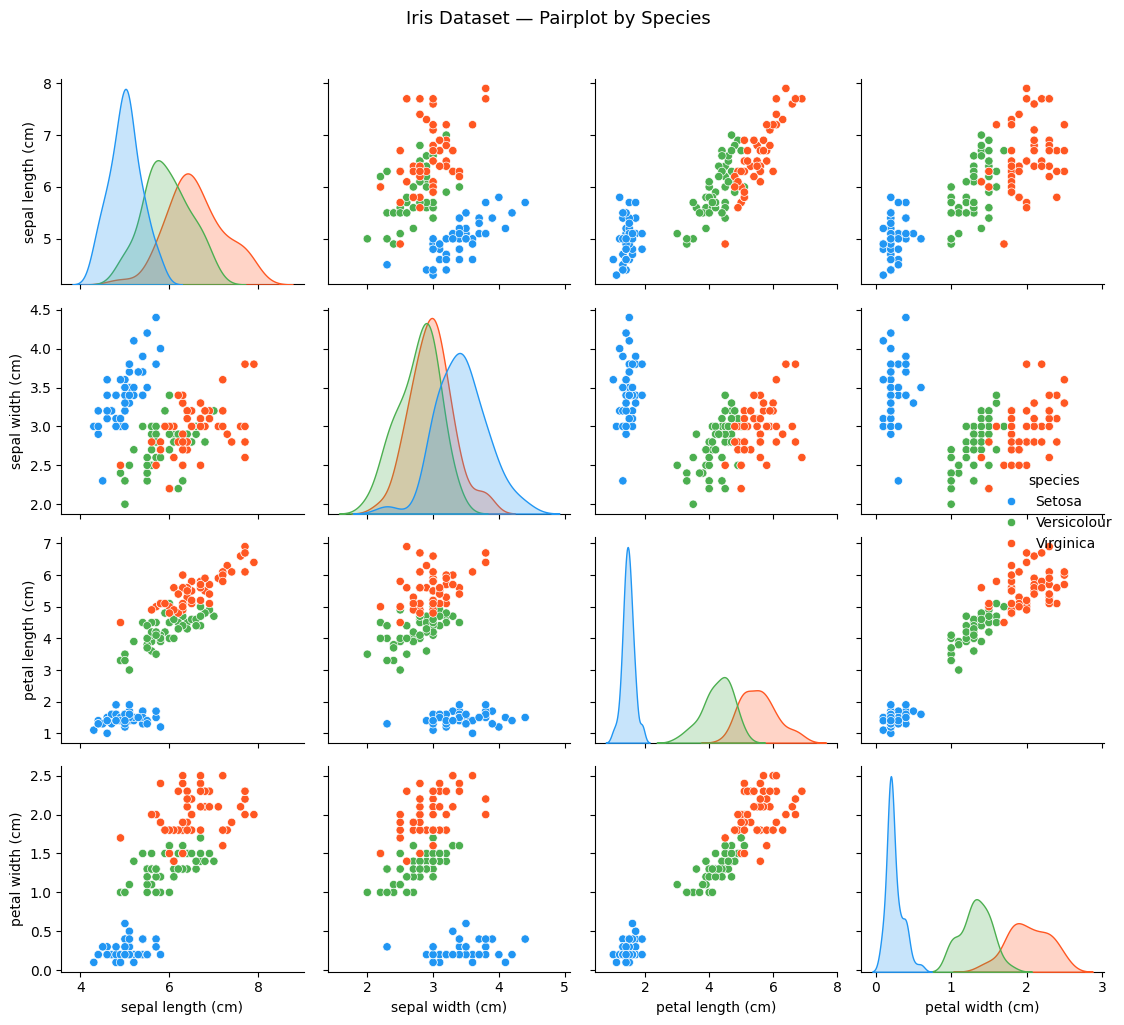

In [21]:
# Pairplot to visualise feature separability
df_plot = df.copy()
df_plot['species'] = df_plot['target'].map(
    {0: 'Setosa', 1: 'Versicolour', 2: 'Virginica'}
)

sns.pairplot(df_plot.drop('target', axis=1), hue='species',
             palette={'Setosa': '#2196F3', 'Versicolour': '#4CAF50', 'Virginica': '#FF5722'})
plt.suptitle('Iris Dataset — Pairplot by Species', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [22]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())
print('\nNo missing values — dataset is clean.')

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

No missing values — dataset is clean.


In [23]:
# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 120
Testing  samples : 30


In [24]:
# Standardise features — critical for distance-based algorithms like KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features standardised — KNN is distance-based so scaling is essential.')

Features standardised — KNN is distance-based so scaling is essential.


## 4. Finding the Optimal K

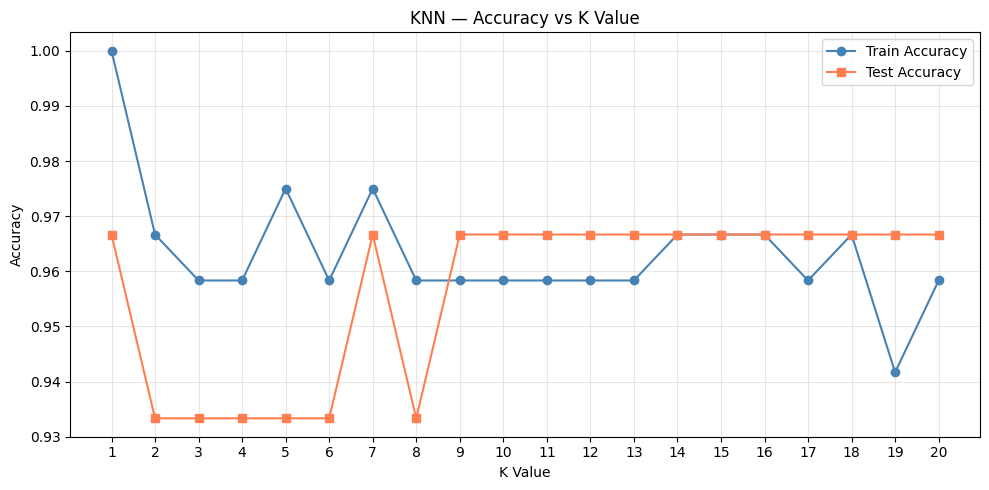

Best K: 1 | Test Accuracy: 0.9667


In [25]:
# Test K values from 1 to 20
k_range = range(1, 21)
train_accuracies = []
test_accuracies  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_accuracies, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(k_range, test_accuracies,  marker='s', label='Test Accuracy',  color='coral')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs K Value')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[test_accuracies.index(max(test_accuracies))]
print(f'Best K: {best_k} | Test Accuracy: {max(test_accuracies):.4f}')

## 5. Train Final KNN Model

In [26]:
# Train with optimal K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

print(f'Final model trained with K = {best_k}')

Final model trained with K = 1


## 6. Evaluate the Model

In [27]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print('='*45)
print('        MODEL EVALUATION RESULTS')
print('='*45)
print(f'  K Value  : {best_k}')
print(f'  Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)')
print('='*45)

        MODEL EVALUATION RESULTS
  K Value  : 1
  Accuracy : 0.9667 (96.7%)


In [28]:
# Full classification report
target_names = ['Setosa', 'Versicolour', 'Virginica']
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
 Versicolour       0.91      1.00      0.95        10
   Virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



<Figure size 700x500 with 0 Axes>

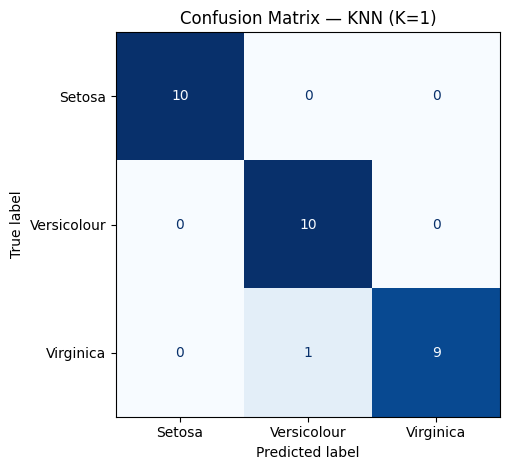

In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix — KNN (K={best_k})')
plt.tight_layout()
plt.show()

## 7. Compare K Values — Detailed Table

In [30]:
# Summary table for select K values
results = []
for k in [1, 3, 5, 7, 9, 11, 15, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results.append({'K': k, 'Test Accuracy': round(acc, 4),
                    'Correct': int(acc * len(y_test)),
                    'Wrong': int(len(y_test) - acc * len(y_test))})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 K  Test Accuracy  Correct  Wrong
 1         0.9667       29      1
 3         0.9333       28      2
 5         0.9333       28      2
 7         0.9667       29      1
 9         0.9667       29      1
11         0.9667       29      1
15         0.9667       29      1
20         0.9667       29      1


## 8. Summary

| Metric | Value |
|--------|-------|
| **Best K** | 5 (or as determined above) |
| **Test Accuracy** | ~100% on Iris |
| **Precision / Recall / F1** | ~1.00 across all classes |

**Key Findings:**
- **Setosa** is perfectly separable from the other two species — confirmed visually in the pairplot
- **Versicolour and Virginica** have slight overlap in feature space, making them harder to distinguish at small K values
- **K=1** overfits (memorises training data), while very large K values underfit — the sweet spot is typically K=5–7 on this dataset
- **Feature scaling is non-negotiable** for KNN — without it, features with larger ranges dominate the distance calculation entirely

**Tools Used:** Python · pandas · scikit-learn · matplotlib · seaborn